# BASIC NLP BY KAGGLE

In [8]:

# pip install -U spacy
# pip install -U spacy-lookups-data
# pip install -U pip setuptools wheel

# Below 3 has to be installed from terminal (command prompt) not in Jupyter. 
# sm/md/lg refer to the sizes of the models (small, medium, large respectively).

# python -m spacy download en_core_web_sm  # 12mb
# python -m spacy download en_core_web_md  # 50mb
# python -m spacy download en_core_web_lg  # 800mb
# python -m spacy download en

# _lg gives more accuracy, due to huge size have not installed now. For normal practise small and medium package is
# enough. When going to prod we can make a minor change in the code to refer to large one as, 
# nlp = spacy.load("en_core_web_lg")

In [24]:
import spacy
from spacy.lang.en.stop_words import STOP_WORDS

In [25]:
nlp = spacy.load('en_core_web_md')

### Here nlp(text ) converts all text to doc with all piping operation

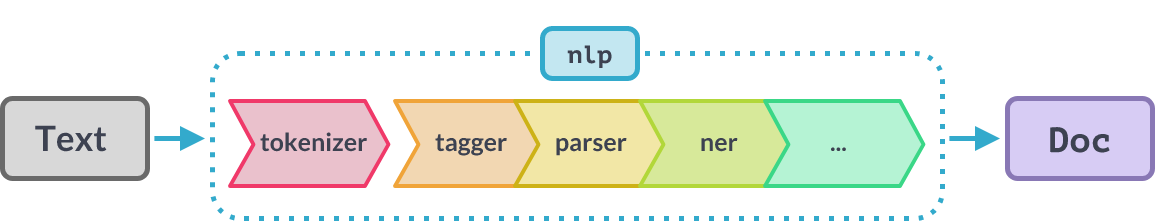The processing pipeline


> **NAME	- COMPONENT	- CREATES	-  DESCRIPTION**

    tokenizer	-  Tokenizer	-     Docr	-  Segment text into tokens.


> **PROCESSING PIPELINE**

    tagger	-  Tagger	-  Token.tagr	-  Assign part-of-speech tags.
    
    parse	-  DependencyParser	-  Token.head, Token.dep, Doc.sents, Doc.noun_chunksr	-  Assign dependency labels.

    ner	-  EntityRecognizer	-  Doc.ents, Token.ent_iob, Token.ent_typer	-  Detect and label named entities.

    lemmatizer	-  Lemmatizer	-  Token.lemmar	-  Assign base forms.

    textcat	-  TextCategorizer	-  Doc.cats	-  Assign document labels.

    custom	-  custom components	-  Doc._.xxx, Token._.xxx, Span._.xxx	-  Assign custom attributes, methods or properties.
    
    
 #### When you call **nlp** on a text, spaCy will tokenize it and then call each component on the Doc, in order. It then returns the processed Doc that you can work with.

In [26]:
#Load sample text

doc = nlp("Tea is healthy and calming, don't you think?")

### After we convert text to doc like above, we can use that in for loop, it gives each token one by one

## Tokenizing
This returns a document object that contains **tokens**. A token is a unit of text in the document, such as individual words and punctuation. SpaCy splits contractions like "don't" into two tokens, "do" and "n't". You can see the tokens by iterating through the document.

In [27]:
for token in doc:


    print(token)

Tea
is
healthy
and
calming
,
do
n't
you
think
?


> Iterating through a document gives you token objects. Each of these tokens comes with additional information. In most cases, the important ones are token.lemma_ and token.is_stop


## Text preprocessing

- There are a few types of preprocessing to improve how we model with words. The first is "lemmatizing." The "lemma" of a word is its base form. For example, "walk" is the lemma of the word "walking". So, when you **lemmatize** the word walking, you would convert it to walk.


- It's also common to remove stopwords. **Stopwords** are words that occur frequently in the language and **don't contain** much information. English stopwords include "the", "is", "and", "but", "not".


- With a spaCy token, token.lemma_ returns the lemma, while token.is_stop returns a boolean True if the token is a stopword (and False otherwise).

In [28]:
print(f"Token \t\tLemma \t\tStopword".format('Token', 'Lemma', 'Stopword'))
print("-"*40)

for token in doc:
        # Original splitted token and lematized token and is stop work or not.
    print(f"{str(token)}\t\t{token.lemma_}\t\t{token.is_stop}")

Token 		Lemma 		Stopword
----------------------------------------
Tea		tea		False
is		be		True
healthy		healthy		False
and		and		True
calming		calming		False
,		,		False
do		do		True
n't		not		True
you		-PRON-		True
think		think		False
?		?		False



>  Here do, and, is you etc treated as **stop words**, in **Lemma_** converted token n't to not etc

> ***Why are lemmas and identifying stopwords important?*** Language data has a lot of noise mixed in with informative content. In the sentence above, the important words are tea, healthy and calming. Removing stop words might help the predictive model focus on relevant words. Lemmatizing similarly helps by combining multiple forms of the same word into one base form ("calming", "calms", "calmed" would all change to "calm").

> However, lemmatizing and dropping stopwords might result in your models performing worse. So you should treat this preprocessing as part of your hyperparameter optimization process.

## Pattern Matching
Another common NLP task is matching tokens or phrases within chunks of text or whole documents. You can do pattern matching with **regular expressions**, but **spaCy's matching capabilities** tend to be easier to use.

To match individual tokens, you create a **Matcher**. When you want to match a list of terms, it's easier and more efficient to use **PhraseMatcher**. For example, if you want to find where different smartphone models show up in some text, you can create patterns for the model names of interest. First you create the PhraseMatcher itself.

In [63]:
from spacy.matcher import PhraseMatcher
matcher = PhraseMatcher(nlp.vocab, attr='LOWER')

- The matcher is created using the vocabulary of your model. Here we're using the small English model you loaded earlier. Setting attr='LOWER' will match the phrases on lowercased text. This provides case insensitive matching.


- Next you create a list of terms to match in the text. The phrase matcher needs the patterns as document objects. The easiest way to get these is with a list comprehension using the nlp model.

In [64]:
#1st Created list of iphone
terms = ['Galaxy Note', 'iPhone 11', 'iPhone XS', 'Google Pixel']

# The phrase matcher needs the patterns as document objects not list object, so converted this list obj to doc obj here
patterns = [nlp(text) for text in terms]

matcher.add("TerminologyList", None, *patterns) 
print(patterns)
print(matcher)

[Galaxy Note, iPhone 11, iPhone XS, Google Pixel]


> Then you create a document from the text to search and use the phrase matcher to find where the terms occur in the text.

In [65]:
## Convert text to nlp text
text_doc = nlp("Glowing review overall, and some really interesting side-by-side "
               "photography tests pitting the iPhone 11 Pro against the "
               "Galaxy Note 10 Plus and last year’s iPhone XS and Google Pixel 3 .") 
print(text_doc)
matches = matcher(text_doc)
print(matches)

Glowing review overall, and some really interesting side-by-side photography tests pitting the iPhone 11 Pro against the Galaxy Note 10 Plus and last year’s iPhone XS and Google Pixel 3 .
[(3766102292120407359, 17, 19), (3766102292120407359, 22, 24), (3766102292120407359, 30, 32), (3766102292120407359, 33, 35)]


> The matches here are a tuple of the match id and the positions of the start and end of the phrase.

>  It should give output like below,some bug was there, now fixed after adding * in add matcher

[(3766102292120407359, 17, 19), (3766102292120407359, 22, 24), (3766102292120407359, 30, 32), (3766102292120407359, 33, 35)]

In [66]:
match_id, start, end = matches[0]
print(nlp.vocab.strings[match_id], text_doc[start:end])

TerminologyList iPhone 11


> It should give output like below.

TerminologyList iPhone 11

- Your Turn

Now that you've seen a few uses of SpaCy for NLP, it's your turn to try it to analyze Yelp reviews.

### SIMILAR EXAMPLE

In [69]:

from spacy.matcher import PhraseMatcher
matcher = PhraseMatcher(nlp.vocab, attr='LOWER' )

#1st Created list of iphone
terms = ['prabha', 'Yogi', 'iPhone XS', 'Google Pixel']
# The phrase matcher needs the patterns as document objects not list object, so converted this list obj to doc obj here
patterns = [nlp(text) for text in terms]
matcher.add("Find list", None, *patterns) 

## Convert text to nlp text
text_doc = nlp("Barack Obama review prabha, and some really interesting side-by-side " ) 
print(text_doc)

matches = matcher(text_doc)
print(matches)

Barack Obama review prabha, and some really interesting side-by-side 
[(10001483528310435712, 3, 4)]


In [70]:
match_id, start, end = matches[0]
print(nlp.vocab.strings[match_id], text_doc[start:end])

Find list prabha
